In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion","fargo_fiducial_closer_companion",  
             "fargo_fiducial_2gen",]

labels = ["$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 0.56M_{jup}$", "$r_1 = 2.28r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_p = 5M_{jup}$",
          "$r_1 = 2.0r_0$, $M_{p,2} = 2.5M_{jup}$", "$r_1 = 2.0r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$, $M_{p,2} = 2.5M_{jup}$ feelings", 
          "$r_1 = 2.0r_0$, $M_{p,2} = 0.56M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 1.25M_{jup}$","$r_1 = 1.7r_0$, $M_{p,2} = 0.56M_{jup}$",
          "$r_1 = 1.7r_0$, $M_{p,2} = 2.5M_{jup}$", "fiducial, no companion"]

labels_n = ["$r_1 = 2.28r_0$,\n$M_{p,2} = 2.5M_{jup}$","$r_1 = 2.28r_0$,\n$M_{p,2} = 0.56M_{jup}$", "$r_1 = 2.28r_0$,\n$M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$,\n$M_p = 5M_{jup}$",
          "$r_1 = 2.0r_0$,\n$M_{p,2} = 2.5M_{jup}$", "$r_1 = 2.0r_0$,\n$M_{p,2} = 1.25M_{jup}$","$r_1 = 2.28r_0$,\n$M_{p,2} = 2.5M_{jup}$ feelings", 
          "$r_1 = 2.0r_0$,\n$M_{p,2} = 0.56M_{jup}$","$r_1 = 1.7r_0$,\n$M_{p,2} = 1.25M_{jup}$","$r_1 = 1.7r_0$,\n$M_{p,2} = 0.56M_{jup}$",
          "$r_1 = 1.7r_0$,\n$M_{p,2} = 2.5M_{jup}$", "fiducial, no companion"]

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

rho_mean = np.mean(rho_cube, axis=3)

/scratch/3803937/ipykernel_481729/101483249.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[-1][-1]),cmap=cm.Oranges_r)


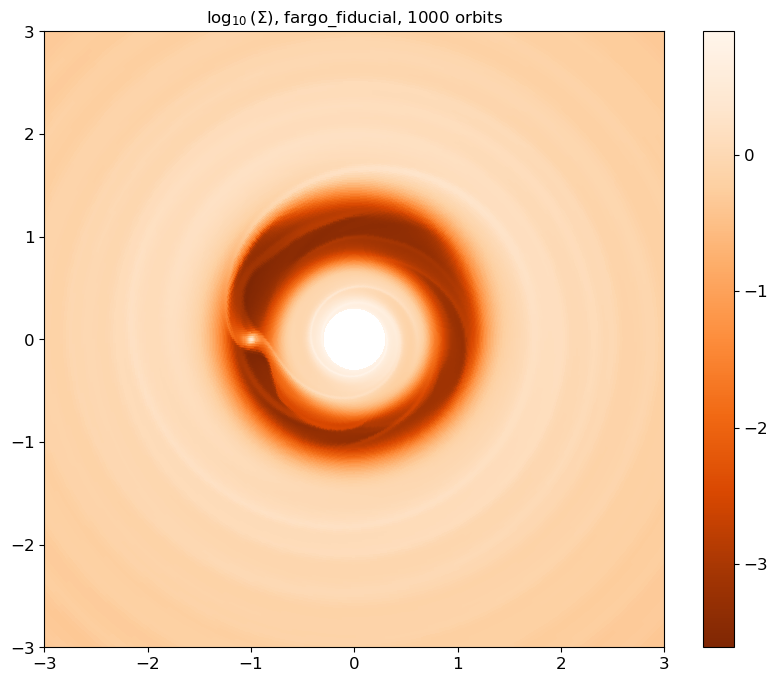

In [4]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
philist = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, philist, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(10,8))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.pcolormesh(X, Y,np.log10(rho_cube[-1][-1]),cmap=cm.Oranges_r)
plt.title(f"$\\log_{{10}} \\left(\\Sigma\\right)$, {paths[-1][43:-5]}, {(frames[-1])*10} orbits")
plt.colorbar()

# Proper masks

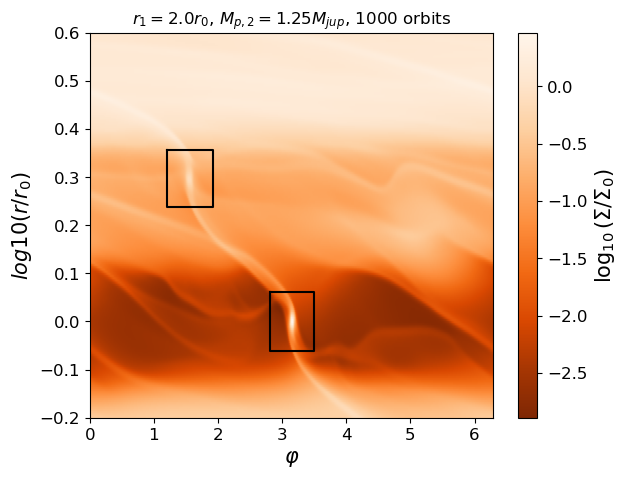

In [5]:
%matplotlib inline
r_min = 0.3
r_max = 7

r_cut = [101,128]
phi_cut = [171,213]


phi_2 = [0,148,370,48,255,95,82,185,10,175,30,0]
r_2 = [193,193,193,193,180,180,193,180,165,165,165,0]


r_in_log = np.log10(r_list[r_cut[1]])
r_out_log = np.log10(r_list[r_cut[0]])
phi_left = philist[phi_cut[0]]
phi_right = philist[phi_cut[1]]

lim = 0.5


frame = 100

for it,i in enumerate([5]):
    path = paths[i]
    r_cut_2 = [r_2[i]-13, (r_2[i]+13)%300]
    phi_cut_2 = [phi_2[i]-22, (phi_2[i]+22)%384]
    
    r_in_log2 = np.log10(r_list[r_cut_2[1]])
    r_out_log2 = np.log10(r_list[r_cut_2[0]])
    phi_left2 = philist[phi_cut_2[0]]
    phi_right2 = philist[phi_cut_2[1]]

    plt.figure(figsize=(6.5,5))
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])#,clim = (np.log10(0.1),np.log10(1.6)))
    plt.plot([phi_left, phi_right, phi_right, phi_left, phi_left],[r_in_log,r_in_log, r_out_log, r_out_log, r_in_log], color="k")
    if phi_left2<phi_right2:
        plt.plot([phi_left2, phi_right2, phi_right2, phi_left2, phi_left2],[r_in_log2,r_in_log2, r_out_log2, r_out_log2, r_in_log2], color="k")
    else:
        plt.plot([phi_left2, 2*np.pi, 2*np.pi, phi_left2, phi_left2],[r_in_log2,r_in_log2, r_out_log2, r_out_log2, r_in_log2], color="k")
        plt.plot([phi_right2, 0, 0, phi_right2, phi_right2],[r_in_log2,r_in_log2, r_out_log2, r_out_log2, r_in_log2], color="k")
        
    #plt.plot(philist[second_planet_phi]*np.ones(2), [-0.5,0.8])
    #plt.plot([0,2*np.pi], np.log10(r_list[r_cut_2])*np.ones(2))
    plt.title(f"{labels[i]}, {(frame)*10} orbits")
    plt.ylim(-0.2,0.6)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar(label="$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$")
plt.savefig("img/cut-out-piece-gap-depth2.png",bbox_inches="tight",)
    
plt.show()
    




In [6]:
np.interp(2.0, r_list, range(len(r_list)))

np.float64(180.68367374189916)

(12, 4, 300, 384)
[-22, 22]
[126, 170]
[348, 392]
[26, 70]
[233, 277]
[73, 117]
[60, 104]
[163, 207]
[-12, 32]
[153, 197]
[8, 52]
[-22, 22]


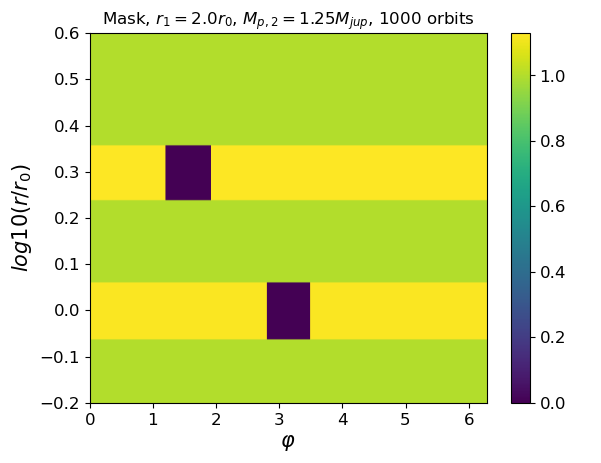

(12, 4, 300, 384)
(12, 4, 300)


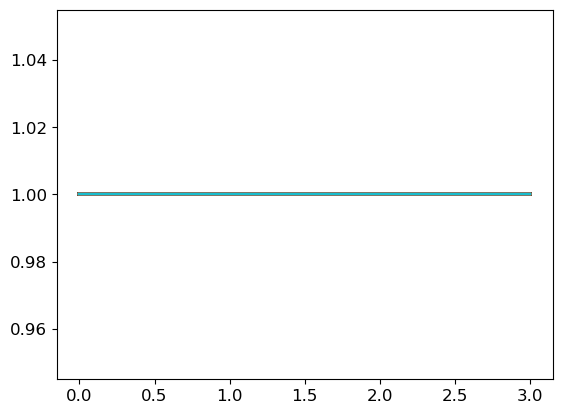

In [6]:


#rho_slice_mean = np.mean(rho_slice, axis=3)
mask = np.ones(rho_cube[:,:,:,:].shape)
print(mask.shape)
mask[:,:,r_cut[0]:r_cut[1]] = len(philist)/(len(philist)-(phi_cut[1]-phi_cut[0]))
mask[:,:,r_cut[0]:r_cut[1],phi_cut[0]:phi_cut[1]] = 0

for i in range(len(mask)):
    r_cut_2 = [r_2[i]-13, r_2[i]+13]
    phi_cut_2 = [phi_2[i]-22, phi_2[i]+22]
    print(phi_cut_2)
    if r_cut_2[0]==0:
        continue
    if phi_cut_2[0]<0:
        mask[i,:,r_cut_2[0]:r_cut_2[1]] = len(philist)/(len(philist)-(phi_cut_2[1]-phi_cut_2[0]))
        mask[i,:,r_cut_2[0]:r_cut_2[1],:phi_cut_2[1]] = 0
        mask[i,:,r_cut_2[0]:r_cut_2[1],phi_cut_2[0]:] = 0
    else:
        mask[i,:,r_cut_2[0]:r_cut_2[1]] = len(philist)/(len(philist)-(phi_cut_2[1]-phi_cut_2[0]))
        mask[i,:,r_cut_2[0]:r_cut_2[1],phi_cut_2[0]:phi_cut_2[1]] = 0

a=5
plt.imshow(mask[a][0], origin="lower",aspect="auto",extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
plt.colorbar(label=" ")
plt.title(f"Mask, {labels[a]}, {(frame)*10} orbits")
#plt.ylim(-0.2,0.6)
plt.ylabel("$log10(r/r_0)$")
plt.xlabel("$\\varphi$")
plt.ylim(-0.2,0.6)

plt.savefig("img/mask_companion.PNG", bbox_inches="tight")
plt.show()

print(mask.shape)
print(np.mean(mask, axis=3).shape)
plt.plot(np.mean(mask, axis=3)[:][-1])


rho_mean_clean = np.mean(rho_cube*mask, axis=3)
rho_mean = np.mean(rho_cube, axis=3)

Text(0.5, 1.0, '1000 orbits')

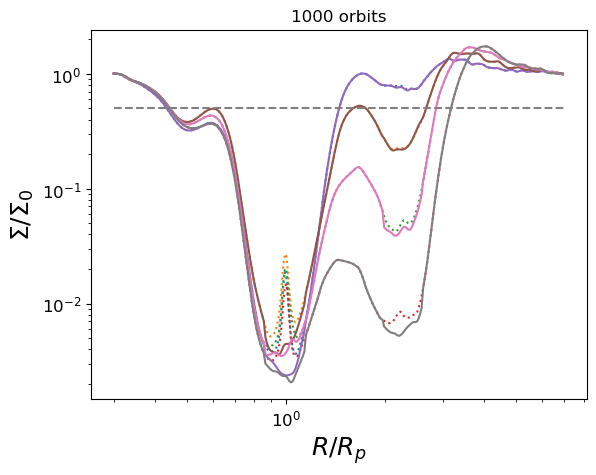

In [8]:
rho_mean_clean = np.mean(rho_cube*mask, axis=3)
index_for_comp_mass=[1,2,0,3]
for i in index_for_comp_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}",linestyle="dotted")
for i in index_for_comp_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean[i][0],label=f"{path[43:-5]}")
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
#plt.legend()

# Finding gap depths

/scratch/3196814/ipykernel_3101013/3053216403.py:24: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_2[it]:
/scratch/3196814/ipykernel_3101013/3053216403.py:20: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth[it]:


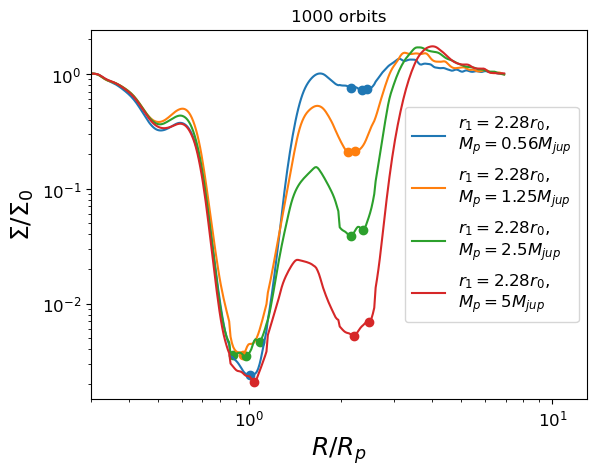

Text(0, 0.5, 'Gap depth')

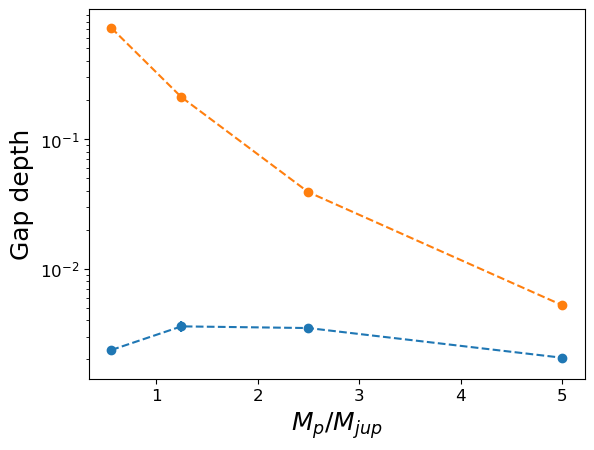

In [16]:
def ufloat_arr(arr):
    values= [ee.nominal_value for ee in arr]
    errs = [ee.std_dev for ee in arr]
    return values, errs

from uncertainties import ufloat
from scipy.signal import argrelextrema
gap_depth = [1,1,1,1]
gap_depth_2 = [1,1,1,1]
index_for_comp_mass=[1,2,0,3]

for it,i in enumerate(index_for_comp_mass):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = argrelextrema(func, np.less)
    local_max_clean = []
    for l in local_max[0]:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth[it]:
                gap_depth[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
        if r_list[l]<2.5 and r_list[l]>2.1:
            local_max_clean.append(l)
            if func[l]< gap_depth_2[it]:
                gap_depth_2[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=labels_n[i])#f"{path[58:-5]}")
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)

    
#plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="center right")
plt.xlim(0.3,13)

plt.savefig("img/gap_depth_norm.png", bbox_inches="tight")
plt.show()

plt.errorbar([0.56,1.25,2.5,5],ufloat_arr(gap_depth)[0], yerr = ufloat_arr(gap_depth)[1],linestyle="--", marker="o", label="first gap")
plt.errorbar([0.56,1.25,2.5,5],ufloat_arr(gap_depth_2)[0], yerr = ufloat_arr(gap_depth_2)[1],linestyle="--", marker="o", label="second gap")
plt.yscale("log")
plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Gap depth")




/scratch/3196814/ipykernel_3101013/2558699895.py:19: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_close[it]:
/scratch/3196814/ipykernel_3101013/2558699895.py:28: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_close_2[it]:


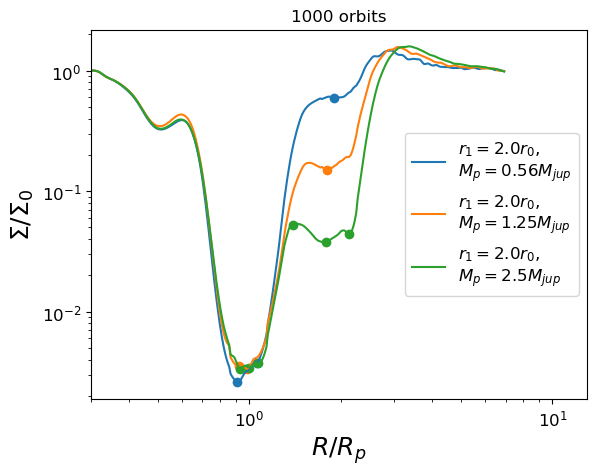

Text(0, 0.5, 'Gap depth')

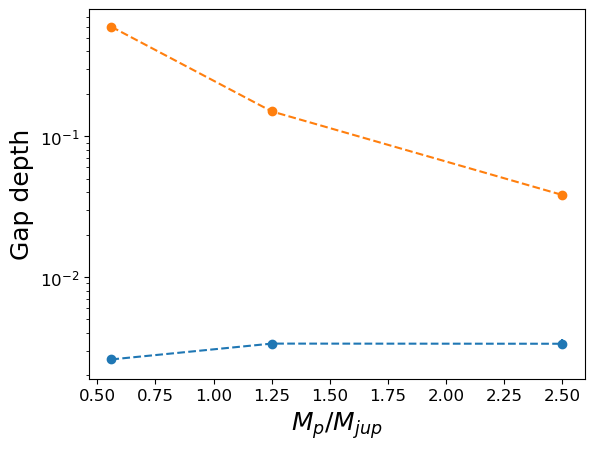

In [17]:

from scipy.signal import argrelextrema
from scipy.signal import find_peaks
gap_depth_close = [1,1,1]
gap_depth_close_2 = [1,1,1]
index_for_comp_close=[7,5,4]


for it,i in enumerate(index_for_comp_close):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = find_peaks(-func)#argrelextrema(func, np.less,order=1)
    local_max = list(local_max[0])
    #local_max.append(np.int64(170))
    #print(local_max)
    local_max_clean =[]
    for l in local_max:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth_close[it]:
                gap_depth_close[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
        if r_list[l]<2.5 and r_list[l]>2.1:
            local_max_clean.append(l)
            if func[l]< gap_depth_close_2[it]:
                gap_depth_close_2[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
                #print(func[l], func[170])
    add_me = 0
    for l in range(170,190):
        if func[l]< gap_depth_close_2[it]:
            gap_depth_close_2[it] =  ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
            add_me = l
    local_max_clean.append(add_me)
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=labels_n[i])
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)


        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="center right")
plt.xlim(0.3,13)

plt.savefig("img/gap_depth_close.png", bbox_inches="tight")
#plt.xlim(1,2.5)
plt.show()
plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_close)[0], yerr = ufloat_arr(gap_depth_close)[1],linestyle="--", marker="o", label="first gap")
plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_close_2)[0], yerr = ufloat_arr(gap_depth_close_2)[1],linestyle="--", marker="o", label="second gap")

plt.yscale("log")
plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Gap depth")
#plt.ylim(1e-4,1e-1)




/scratch/3196814/ipykernel_3101013/1033820813.py:20: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_closer[it]:
/scratch/3196814/ipykernel_3101013/1033820813.py:30: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_closer_2[it]:
/scratch/3196814/ipykernel_3101013/1033820813.py:24: FutureWarning: AffineScalarFunc.__gt__() is deprecated. It will be removed in a future release.
  if func[l]< gap_depth_closer_2[it]:


0.13187032880708677 0.1485259195236289
0.056355730589238755 0.06574750451984596
1.643723327999073 1.9444083644854357


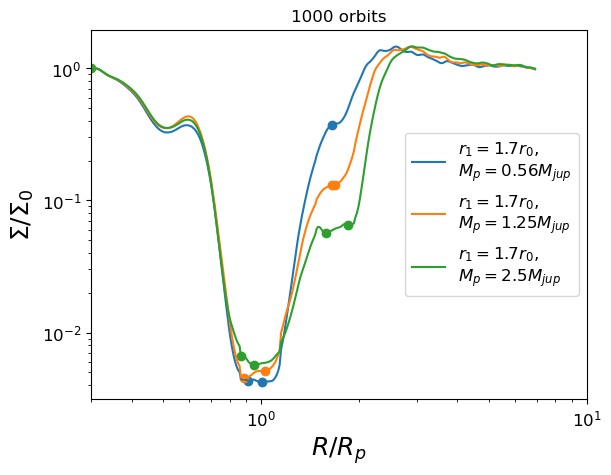

Text(0, 0.5, 'Gap depth')

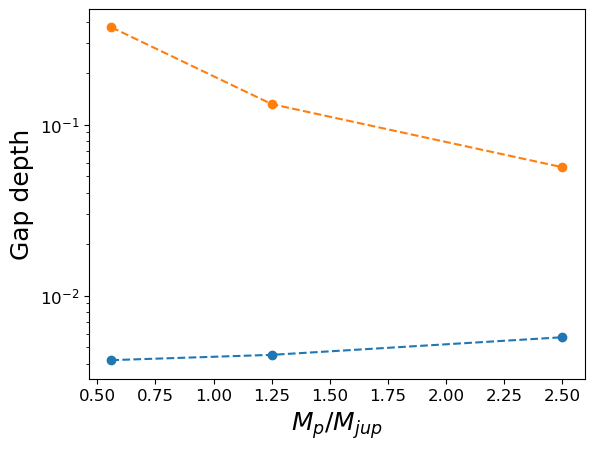

In [18]:

from scipy.signal import argrelextrema
from scipy.signal import find_peaks
gap_depth_closer = [1,1,1]
gap_depth_closer_2 = [1,1,1]

index_for_closer=[9,8,10]


for it,i in enumerate(index_for_closer):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = find_peaks(-func)#argrelextrema(func, np.less,order=1)
    local_max = list(local_max[0])
    #local_max.append(np.int64(170))
    #print(local_max)
    local_max_clean =[]
    for l in local_max:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth_closer[it]:
                gap_depth_closer[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
        if r_list[l]<2.2 and r_list[l]>1.5:
            local_max_clean.append(l)
            if func[l]< gap_depth_closer_2[it]:
                gap_depth_closer_2[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
                print(func[l], func[170])
           
    add_me = 0
    for l in range(162,178):
        if func[l]< gap_depth_closer_2[it]:
            gap_depth_closer_2[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
            add_me = l
    local_max_clean.append(add_me)
    
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=labels_n[i])#f"{path[58:-5]}")
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)

    
#plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")
print(r_list[162],r_list[178])
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="center right")
plt.xlim(0.3,10)

plt.savefig("img/gap_depth_closer.png", bbox_inches="tight")

plt.show()

plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_closer)[0], yerr = ufloat_arr(gap_depth_close)[1],linestyle="--", marker="o", label="first gap")
plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_closer_2)[0], yerr = ufloat_arr(gap_depth_close_2)[1],linestyle="--", marker="o", label="second gap")
plt.yscale("log")
plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Gap depth")
#plt.ylim(1e-4,1e-1)




/scratch/3196814/ipykernel_3101013/180312592.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


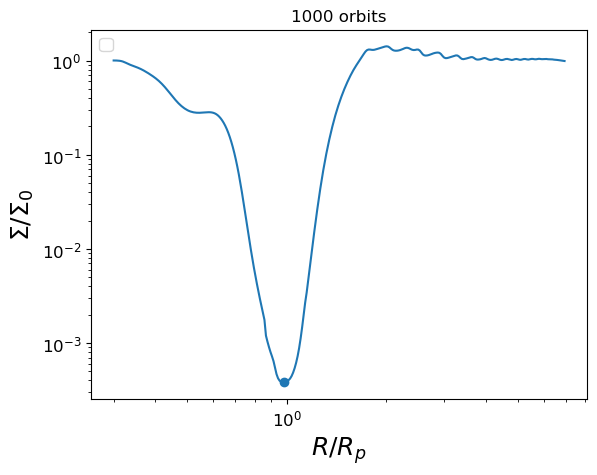

In [12]:

from scipy.signal import argrelextrema
from scipy.signal import find_peaks
gap_depth_fid = [1]

index_for_fid = [11]


for it,i in enumerate(index_for_fid):
    path = paths[i]
    func= (rho_mean_clean[i][-1]/rho_mean_clean[i][0])
    local_max = find_peaks(-func)#argrelextrema(func, np.less,order=1)
    local_max = list(local_max[0])
    #local_max.append(np.int64(170))
    #print(local_max)
    local_max_clean =[]
    for l in local_max:
        if r_list[l]<1.5 and r_list[l]>0.7:
            local_max_clean.append(l)
            if func[l]< gap_depth_fid[it]:
                gap_depth_fid[it] = ufloat(func[l], max(abs(func[l+2]-func[l]), abs(func[l]-func[l-2])))
                
    plt.plot(r_list,rho_mean_clean[i][-1]/rho_mean_clean[i][0], label=f"{path[58:-5]}")
    plt.scatter(r_list[local_max_clean],rho_mean_clean[i][-1][local_max_clean]/rho_mean_clean[i][0][local_max_clean],)

    
#plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper left")
plt.savefig("img/gap_depth_mass.png")
#plt.xlim(1,2.5)
plt.show()




# Summary

In [13]:
def ufloat_arr(arr):
    values= [ee.nominal_value for ee in arr]
    errs = [ee.std_dev for ee in arr]
    return values, errs

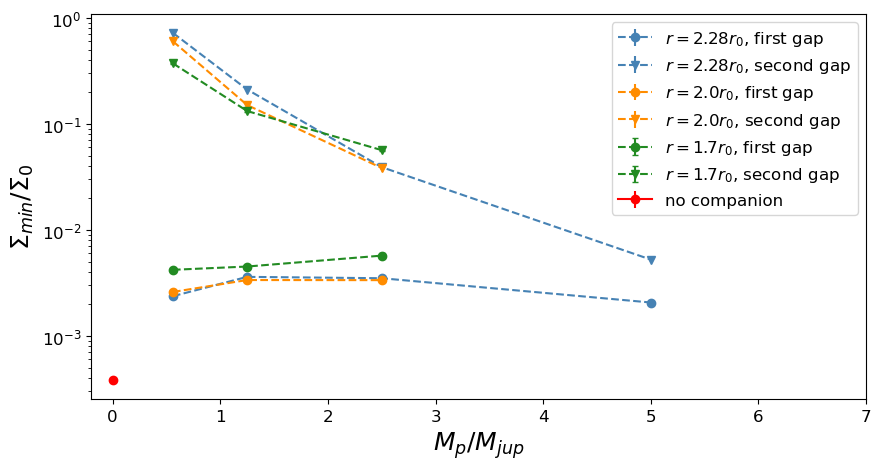

In [15]:
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
mjup = mstar*0.00177/2

r0 = 57
gap_obs_lower = 46.03/r0
gap_obs = 58.5/r0
gap_obs_upper = 64.86/r0

plt.figure(figsize=(10,5))

plt.errorbar([0.56,1.25,2.5,5],ufloat_arr(gap_depth)[0], yerr = ufloat_arr(gap_depth)[1],linestyle="--", marker="o", label="$r = 2.28r_0$, first gap", color="steelblue")
plt.errorbar([0.56,1.25,2.5,5],ufloat_arr(gap_depth_2)[0], yerr = ufloat_arr(gap_depth_2)[1],linestyle="--", marker="v", label="$r = 2.28r_0$, second gap", color="steelblue")

plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_close)[0], yerr = ufloat_arr(gap_depth_close)[1],linestyle="--", marker="o",label="$r = 2.0r_0$, first gap", color="darkorange")
plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_close_2)[0], yerr = ufloat_arr(gap_depth_close_2)[1],linestyle="--", marker="v",label="$r = 2.0r_0$, second gap", color="darkorange")


plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_closer)[0], yerr = ufloat_arr(gap_depth_close)[1],linestyle="--", marker="o", label="$r = 1.7r_0$, first gap", color="forestgreen", capsize=2)
plt.errorbar([0.56,1.25,2.5],ufloat_arr(gap_depth_closer_2)[0], yerr = ufloat_arr(gap_depth_close_2)[1],linestyle="--", marker="v", label="$r = 1.7r_0$, second gap", color="forestgreen", capsize=2)


plt.errorbar([0], ufloat_arr(gap_depth_fid)[0], yerr = ufloat_arr(gap_depth_fid)[1], marker="o", label="no companion", color="red")
plt.yscale("log")
plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("$\\Sigma_{min}/\\Sigma_0$")
plt.xlim(-0.2,7)
plt.legend()

plt.savefig("img/companion_gap_depth.png", bbox_inches="tight")